<a href="https://colab.research.google.com/github/dishanth2k6/Company-Projects/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
from google.colab import files
import io


uploaded = files.upload()


file_name = list(uploaded.keys())[0]
print(f"\nSuccessfully uploaded: {file_name}")

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv

Successfully uploaded: WA_Fn-UseC_-Telco-Customer-Churn.csv


In [4]:
# Load the data from the upload buffer
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# Drop unique identifier column
df.drop(columns=['customerID'], inplace=True, errors='ignore')

# Clean and fix TotalCharges column (handles hidden empty spaces)
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = df['TotalCharges'].astype(float)
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Convert Target variable 'Churn' to binary [cite: 3]
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Normalize column names to lowercase to make coding easier
df.columns = df.columns.str.lower()

# Map binary categorical options
df['partner'] = df['partner'].map({'No': 0, 'Yes': 1})
df['dependents'] = df['dependents'].map({'No': 0, 'Yes': 1})
df['phoneservice'] = df['phoneservice'].map({'No': 0, 'Yes': 1})
df['paperlessbilling'] = df['paperlessbilling'].map({'No': 0, 'Yes': 1})
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# One-Hot Encode remaining multi-class categories [cite: 4, 6]
categorical_cols = ['internetservice', 'onlinesecurity', 'onlinebackup',
                    'deviceprotection', 'techsupport', 'streamingtv',
                    'streamingmovies', 'contract', 'paymentmethod']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Data loaded and cleaned successfully! Shape:", df.shape)
df.head()

Data loaded and cleaned successfully! Shape: (7043, 30)


/tmp/ipykernel_490/468688861.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,paperlessbilling,monthlycharges,totalcharges,...,techsupport_Yes,streamingtv_No internet service,streamingtv_Yes,streamingmovies_No internet service,streamingmovies_Yes,contract_One year,contract_Two year,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check
0,0,0,1,0,1,0,No phone service,1,29.85,29.85,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,No,0,56.95,1889.50,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,No,1,53.85,108.15,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,No phone service,0,42.30,1840.75,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,No,1,70.70,151.65,...,False,False,False,False,False,False,False,False,True,False


/tmp/ipykernel_490/3100404008.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette='magma')


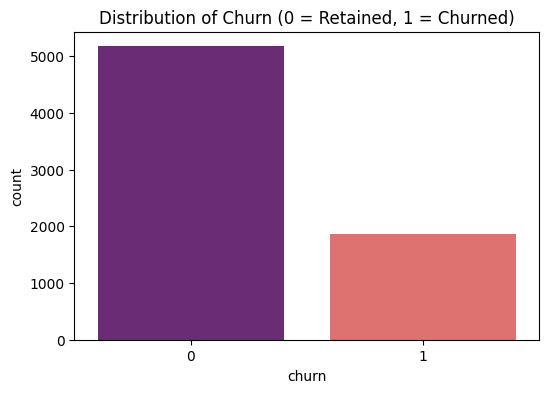

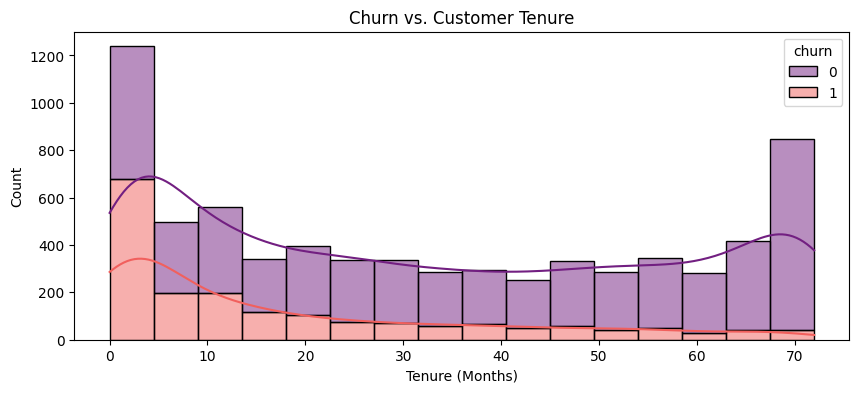

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df, palette='magma')
plt.title('Distribution of Churn (0 = Retained, 1 = Churned)')
plt.show()

plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='tenure', hue='churn', multiple='stack', kde=True, palette='magma')
plt.title('Churn vs. Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.show()

In [6]:
# Separate features and target
X = df.drop(columns=['churn'])
y = df['churn']

# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale continuous numerical data [cite: 4]
scaler = StandardScaler()
numerical_features = ['tenure', 'monthlycharges', 'totalcharges']
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print("Data split and scaled ready for training!")

Data split and scaled ready for training!


In [8]:
import pandas as pd

# Identify categorical columns that still need one-hot encoding
categorical_cols_to_encode = ['multiplelines']

# Apply one-hot encoding to X_train and X_test for the identified columns
# Use get_dummies and align columns to ensure consistency between train and test sets
X_train = pd.get_dummies(X_train, columns=categorical_cols_to_encode, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols_to_encode, drop_first=True)

# Align columns - crucial for consistent feature sets after one-hot encoding
train_cols = X_train.columns
test_cols = X_test.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train[c] = 0

X_test = X_test[train_cols] # Ensure the order of columns is the same

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000).fit(X_train, y_train)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)

print("Logistic Regression and Random Forest models trained!")

Logistic Regression and Random Forest models trained!


In [9]:
# Predictions
lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("=== LOGISTIC REGRESSION PERFORMANCE ===")
print(classification_report(y_test, lr_preds))
print("ROC-AUC Score:", round(roc_auc_score(y_test, lr_probs), 4))

print("\n=== RANDOM FOREST PERFORMANCE ===")
print(classification_report(y_test, rf_preds))
print("ROC-AUC Score:", round(roc_auc_score(y_test, rf_probs), 4))

=== LOGISTIC REGRESSION PERFORMANCE ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC Score: 0.8421

=== RANDOM FOREST PERFORMANCE ===
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC Score: 0.8266


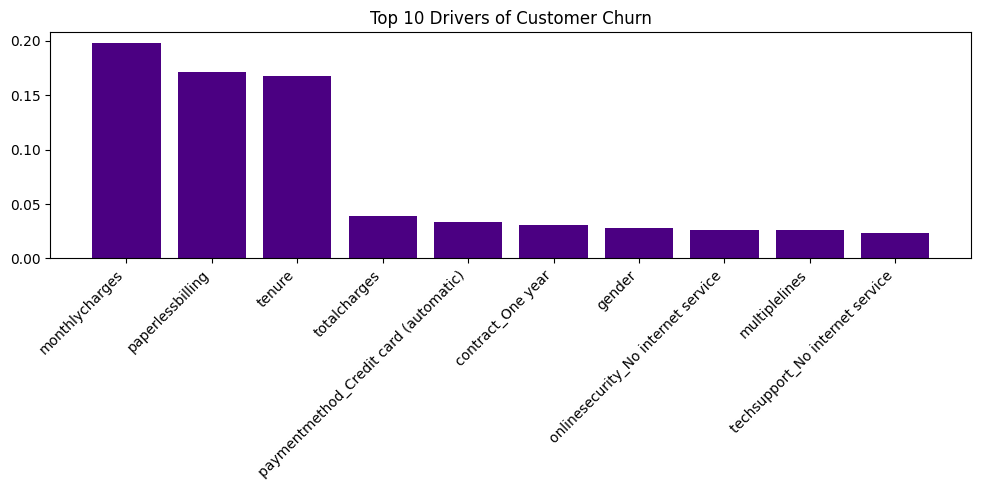

In [10]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 5))
plt.title("Top 10 Drivers of Customer Churn")
plt.bar(range(10), importances[indices], color='indigo', align="center")
plt.xticks(range(10), [X.columns[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()